# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. We use these models because standard linear regression (Ordinary Least Squares) often fails when data does not meet strict assumptions (normal distribution of errors, constant variance)
2. Cross-entropy is effective because it is tailored for probabilistic models and measures the difference between predicted probability distributions and true class labels
3. True
4. False
5. No it doesn't
6. False
7. False

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dropout_df = pd.read_csv('data.csv', sep=';')
dropout_df = dropout_df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']]
dropout_df

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate
...,...,...,...,...,...,...
4419,0,1,0,19,5,Graduate
4420,1,0,0,18,6,Dropout
4421,0,1,1,30,7,Dropout
4422,0,1,1,20,5,Graduate


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = dropout_df[features]
y = (dropout_df['Target'] == 'Dropout').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

model_coef = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})
print("Logistic Regression Coefficients:")
print(model_coef)

intercept = model.intercept_[0]
print(f"\nIntercept: {intercept:.4f}")


Logistic Regression Coefficients:
                   Feature  Coefficient
0                   Debtor     0.542961
1  Tuition fees up to date    -2.488453
2       Scholarship holder    -1.198139
3        Age at enrollment     0.048762

Intercept: 0.4089


<Axes: xlabel='Age at enrollment'>

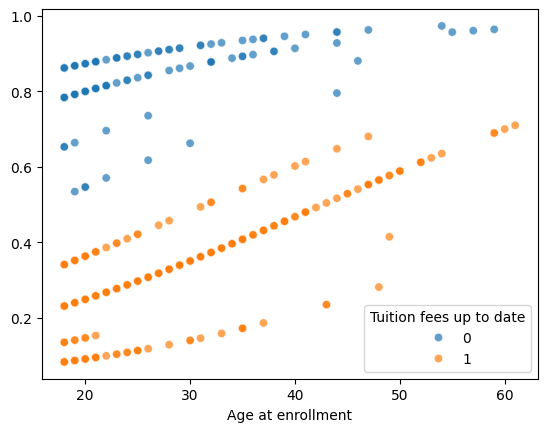

In [59]:
dropout_prob = model.predict_proba(X_test)[:, 1]
scatter_plot = sns.scatterplot(x=X_test['Age at enrollment'], y=dropout_prob
                               , hue=X_test['Tuition fees up to date']
                               , alpha=0.7)
scatter_plot

In [60]:
cf_matrix = confusion_matrix(y_test, model.predict(X_test))
print("Confusion Matrix:")
print(cf_matrix)

Confusion Matrix:
[[541  28]
 [191 125]]


In [61]:
from sklearn.linear_model import LinearRegression


linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_model_coef = pd.DataFrame({
    'Feature': features,
    'Coefficient': linear_model.coef_
})
print("Linear Regression Coefficients:")
print(linear_model_coef)



Linear Regression Coefficients:
                   Feature  Coefficient
0                   Debtor     0.087223
1  Tuition fees up to date    -0.509252
2       Scholarship holder    -0.171111
3        Age at enrollment     0.009178


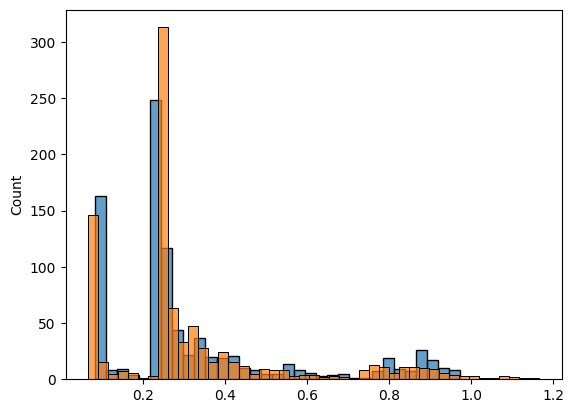

In [62]:
logistic_hist = sns.histplot(dropout_prob, label='Logistic Regression', alpha=0.7)
linear_hist = sns.histplot(linear_model.predict(X_test), label='Linear Regression', alpha=0.7)


In [63]:
from pandas.core.indexes import multi
features = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X = dropout_df[features]
y = dropout_df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
multi_model.fit(X_train, y_train)

hard_predictions = multi_model.predict(X_test)
cf_matrix = confusion_matrix(y_test, hard_predictions)

print(cf_matrix)


print(np.unique(hard_predictions))


predicted_proba = multi_model.predict_proba(X_test)
print(predicted_proba[:5])

print(multi_model.classes_)


[[206   0 110]
 [ 39   0 112]
 [ 18   0 400]]
['Dropout' 'Graduate']
[[0.68113991 0.2101235  0.10873659]
 [0.1718503  0.21387239 0.61427731]
 [0.1361071  0.27087776 0.59301514]
 [0.10751288 0.17685533 0.71563179]
 [0.68113991 0.2101235  0.10873659]]
['Dropout' 'Enrolled' 'Graduate']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


2: Debtor and Age at enrollment has a higher dropout prob while the other 2 has lower. Being up to date definitely seems to reduce dropout rate

3: Being up to date on tuition at younger ages reduces dropout the most. On average it seems like across every age group it reduces probability of dropout

4: predicting positives seems to go well but not that good at predicting negatives

5: Comparing the two it doesn't seem like there is too huge of a difference but logistic seems better in this case

6: Based on the work made young and in debt students tend to drop out the most. Making tuition cheaper seems like a way to have less dropouts

7: It seems to have only predicted dropout and graduated for hard classification but predicted probabilities does predict every class.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [64]:
cirrhosis_df = pd.read_csv('cirrhosis.csv')
cirrhosis_df = cirrhosis_df[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']]
cirrhosis_df

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL
...,...,...,...,...,...
413,1.2,N,NaN,3.0,D
414,0.9,N,NaN,4.0,C
415,1.6,N,NaN,3.0,C
416,0.8,N,NaN,3.0,C


In [65]:
cirrhosis_df = cirrhosis_df.dropna()
print(cirrhosis_df.isnull().sum())

Bilirubin    0
Edema        0
Drug         0
Stage        0
Status       0
dtype: int64


In [66]:
x = cirrhosis_df[['Bilirubin', 'Edema', 'Drug']]
y = ((cirrhosis_df['Status'] == 'C') | (cirrhosis_df['Status'] == 'CL')).astype(int)

x = pd.get_dummies(x, columns=['Edema', 'Drug'], drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)


model_coef = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_[0]
})
print("Logistic Regression Coefficients:")
print(model_coef)

Logistic Regression Coefficients:
        Feature  Coefficient
0     Bilirubin    -0.395757
1       Edema_S    -0.281639
2       Edema_Y    -1.938439
3  Drug_Placebo     0.062181


<Axes: xlabel='Bilirubin'>

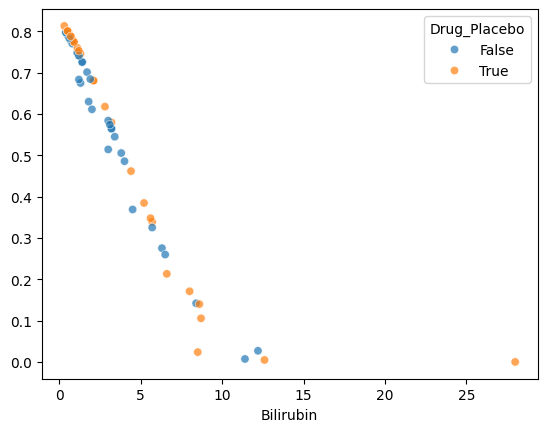

In [67]:
survival_prob = model.predict_proba(x_test)[:, 1]
scatter_plot = sns.scatterplot(x=x_test['Bilirubin'], y=survival_prob
                               , hue=x_test['Drug_Placebo']
                               , alpha=0.7)
scatter_plot

In [68]:
cf_matrix = confusion_matrix(y_test, model.predict(x_test))
print("Confusion Matrix:")
print(cf_matrix)
accuracy = (cf_matrix[0, 0] + cf_matrix[1, 1]) / cf_matrix.sum()
print(f"Accuracy: {accuracy:.4f}")

Confusion Matrix:
[[13 13]
 [ 6 31]]
Accuracy: 0.6984


In [69]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
linear_model_coef = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': linear_model.coef_
})
print("Linear Regression Coefficients:")
print(linear_model_coef)

Linear Regression Coefficients:
        Feature  Coefficient
0     Bilirubin    -0.038888
1       Edema_S    -0.087276
2       Edema_Y    -0.410579
3  Drug_Placebo     0.014622


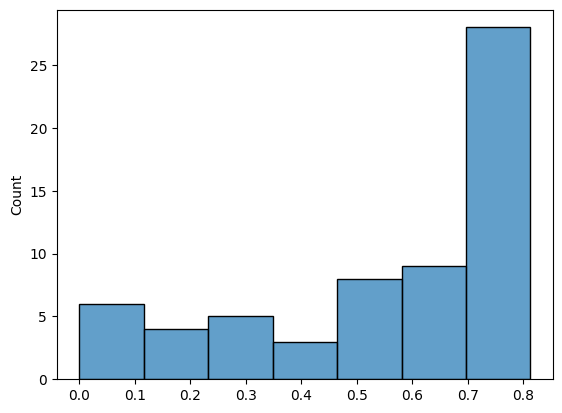

In [70]:

logistic_hist = sns.histplot(survival_prob, label='Logistic Regression', alpha=0.7)

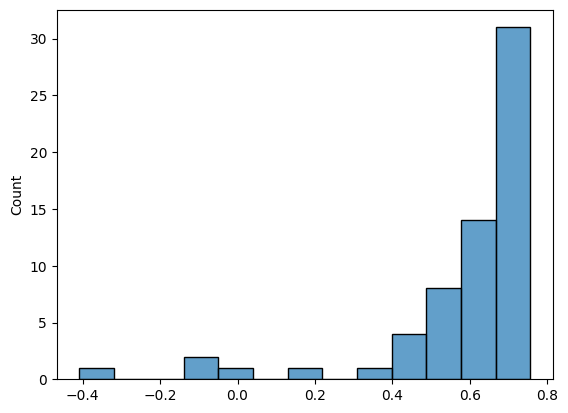

In [71]:
linear_hist = sns.histplot(linear_model.predict(x_test), label='Linear Regression', alpha=0.7)

In [72]:
features = ['Edema', 'Bilirubin']
x = cirrhosis_df[features]
y = cirrhosis_df['Stage']

x = pd.get_dummies(x, columns=['Edema'], drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

hard_predictions = model.predict(x_test)
cf_matrix = confusion_matrix(y_test, hard_predictions)
print(cf_matrix)

print(f"\nClasses in y_test: {sorted(y_test.unique())}")
print(f"Classes predicted: {sorted(set(hard_predictions))}")

probas = model.predict_proba(x_test)
print(probas[:5])


[[ 0  0  3  0]
 [ 0  0 13  1]
 [ 0  0 20  3]
 [ 0  0 16  7]]

Classes in y_test: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Classes predicted: [np.float64(3.0), np.float64(4.0)]
[[8.41002476e-03 1.18451968e-01 4.26314925e-01 4.46823082e-01]
 [2.31164766e-04 4.59653799e-02 1.73764169e-01 7.80039286e-01]
 [8.28014816e-02 2.51510228e-01 3.96515818e-01 2.69172472e-01]
 [8.61059874e-02 2.52225208e-01 3.94977424e-01 2.66691380e-01]
 [1.27497697e-02 1.98302477e-01 4.23137650e-01 3.65810103e-01]]


1: dropped na values

2: Drug seems to have almost no effect. Higher bilirubin lowers survival rate. Edema also lowers survival rate by a lot especially for despite diuretics

3: It seems to have no effect whether you take it or not. Lower levels mean higher survival rates

4: accuracy is 0.6984

5: overall shape of histogram look the same but logistic is definitely better. also weird negatives for linear

6: It seems to only predict stage 3 and 4 but predicted predicts every class

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

1: The derivative of the prediction with respect to the $k$-th feature is:
$$\frac{\partial \hat{y}}{\partial x_k} = b_k$$
For a 1-unit change in $x_k$, the prediction changes by exactly $b_k$. This is constant regardless of the current value of $x_k$ or any other features.

2:  Let $L = b \cdot x$. By the chain rule:
$$\frac{\partial \hat{p}}{\partial x_k} = \frac{\partial}{\partial L}\frac{e^L}{1+e^L} \cdot \frac{\partial L}{\partial x_k} = \hat{p}(1-\hat{p}) \cdot b_k$$
Unlike the linear case, this derivative \textbf{changes as $x$ changes}, since $\hat{p}$ itself depends on $x$. The effect of $b_k$ is scaled by $\hat{p}(1-\hat{p})$, which is maximized at $\hat{p} = 0.5$, giving a maximum marginal effect of $\frac{b_k}{4}$.

So when $\hat{p} \approx 0.5$ (near the decision boundary), $\frac{b_k}{4}$ is a good approximation of how a 1-unit change in $x_k$ affects the prediction. Far from the boundary, when the model is already confident ($\hat{p}$ near 0 or 1), the marginal effect shrinks toward zero.

3: Since $\log\left(\dfrac{\hat{p}}{1-\hat{p}}\right) = b \cdot x = b_0 + \sum_{k=1}^K b_k x_k$, the log odds ratio is linear in $x$, so:
$$\frac{\partial}{\partial x_k}\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_k$$
A 1-unit increase in $x_k$ increases the log odds by exactly $b_k$, unconditionally. This is the most natural interpretation of a logistic regression coefficient.